# Lab 2: Data Preparation for NYC Taxi Fare Forecasting

## Scenario
You work as a data scientist for a taxi company in New York City. Your task is to build a machine learning model that can accurately forecast taxi fares based on various trip characteristics. Before building any predictive model, you need to prepare the data properly - this involves cleaning the dataset, handling missing values, detecting outliers, and creating meaningful features that will help the model make better predictions.

## Goal
Clean a real-world NYC taxi dataset and create meaningful features for fare prediction. By the end of this lab, you'll have a clean, feature-rich dataset ready for machine learning model training.

## Learning Objectives
- Load and explore real-world taxi data
- Handle missing values and data quality issues
- Detect and handle outliers in the dataset
- Engineer temporal and spatial features
- Understand the importance of data preparation in machine learning

## Setup: Create Sample Data (Run this first if you don't have taxi.csv)

If you don't have the NYC taxi dataset, run this cell to create sample data for the lab:

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Create sample taxi data for the lab
np.random.seed(42)
n_samples = 7333

# Generate realistic taxi trip data
base_date = datetime(2011, 1, 1)
dates = [base_date + timedelta(days=np.random.randint(0, 1095), 
                              hours=np.random.randint(0, 24),
                              minutes=np.random.randint(0, 60),
                              seconds=np.random.randint(0, 60))
         for _ in range(n_samples)]

# NYC coordinates (roughly Manhattan area)
pickup_lats = np.random.normal(40.75, 0.03, n_samples)
pickup_lons = np.random.normal(-73.98, 0.02, n_samples)

# Dropoff coordinates (related to pickup but with some variation)
dropoff_lats = pickup_lats + np.random.normal(0, 0.01, n_samples)
dropoff_lons = pickup_lons + np.random.normal(0, 0.01, n_samples)

# Calculate basic distance for fare estimation
distances = np.sqrt((pickup_lats - dropoff_lats)**2 + (pickup_lons - dropoff_lons)**2)
base_fares = 2.5 + distances * 1000 * 0.5 + np.random.gamma(2, 2)

# Add some outliers and data quality issues for realistic data cleaning
outlier_indices = np.random.choice(n_samples, size=50, replace=False)
base_fares[outlier_indices[:25]] = np.random.uniform(0.1, 1.5, 25)  # Low outliers
base_fares[outlier_indices[25:]] = np.random.uniform(200, 500, 25)  # High outliers

# Create the dataset
taxi_data = {
    'fare_amount': np.round(base_fares, 1),
    'pickup_timestamp': [d.strftime('%Y-%m-%d %H:%M:%S UTC') for d in dates],
    'pickup_longitude': np.round(pickup_lons, 6),
    'pickup_latitude': np.round(pickup_lats, 6),
    'dropoff_longitude': np.round(dropoff_lons, 6),
    'dropoff_latitude': np.round(dropoff_lats, 6)
}

df_sample = pd.DataFrame(taxi_data)
df_sample.to_csv('taxi.csv', index=False)

print(f"Sample dataset created with {len(df_sample)} records")
print("File saved as 'taxi.csv'")
print("\nDataset preview:")
df_sample.head()

Sample dataset created with 7333 records
File saved as 'taxi.csv'

Dataset preview:


,fare_amount,pickup_timestamp,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
0,26.0,2013-05-10 14:42:07 UTC,-73.981828,40.750499,-73.961214,40.748411
1,21.5,2013-11-10 06:57:18 UTC,-73.960184,40.776519,-73.957553,40.765177
2,24.3,2011-11-27 10:23:52 UTC,-73.988015,40.798280,-73.974500,40.787364
3,23.6,2013-05-21 23:02:21 UTC,-73.994930,40.699435,-73.994619,40.683525
4,21.0,2013-02-08 23:43:29 UTC,-74.025075,40.740455,-74.017560,40.748130


## Step 1: Load NYC Yellow Cab Data

In this step, we'll load the NYC taxi dataset and explore its structure to understand what data we're working with.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
%matplotlib inline

# Set display options for better output
pd.set_option('display.max_columns', None)
plt.style.use('default')
sns.set_palette("husl")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
# Load the dataset
df = pd.read_csv("taxi.csv")

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Dataset shape: (7333, 6)

Column names:
['fare_amount', 'pickup_timestamp', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']

First 5 rows:


,fare_amount,pickup_timestamp,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
0,26.0,2013-05-10 14:42:07 UTC,-73.981828,40.750499,-73.961214,40.748411
1,21.5,2013-11-10 06:57:18 UTC,-73.960184,40.776519,-73.957553,40.765177
2,24.3,2011-11-27 10:23:52 UTC,-73.988015,40.798280,-73.974500,40.787364
3,23.6,2013-05-21 23:02:21 UTC,-73.994930,40.699435,-73.994619,40.683525
4,21.0,2013-02-08 23:43:29 UTC,-74.025075,40.740455,-74.017560,40.748130


In [4]:
# Examine the dataset structure
print("Dataset Info:")
df.info()
print("\n" + "="*50)
print("Summary Statistics:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7333 entries, 0 to 7332
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fare_amount        7333 non-null   float64
 1   pickup_timestamp   7333 non-null   object 
 2   pickup_longitude   7333 non-null   float64
 3   pickup_latitude    7333 non-null   float64
 4   dropoff_longitude  7333 non-null   float64
 5   dropoff_latitude   7333 non-null   float64
dtypes: float64(5), object(1)
memory usage: 343.9+ KB

Summary Statistics:


,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
count,7333.000000,7333.000000,7333.000000,7333.000000,7333.000000
mean,22.931201,-73.980183,40.750106,-73.979999,40.749972
std,19.688769,0.019739,0.030112,0.022139,0.031924
min,0.200000,-74.049901,40.634309,-74.063783,40.615435
25%,19.500000,-73.993854,40.729521,-73.995054,40.728210
50%,21.600000,-73.979965,40.750154,-73.979710,40.749527
75%,24.000000,-73.966675,40.770805,-73.965305,40.771585
max,480.800000,-73.906168,40.884373,-73.899130,40.892908


**Code Explanation**: We start by importing essential Python libraries for data manipulation (pandas), numerical operations (numpy), and visualization (matplotlib, seaborn). The dataset contains pickup and dropoff information for NYC taxi rides including timestamps, locations, and fare amounts. The `.info()` method shows us the data types and identifies any missing values, while `.describe()` provides statistical summaries of numerical columns.

## Step 2: Handle Missing Data and Detect Outliers

Now we'll check for missing values, handle data quality issues, and detect outliers that could impact our model.

In [5]:
# Check for missing values
print("Missing values per column:")
missing_data = df.isnull().sum()
print(missing_data)
print(f"\nTotal missing values: {missing_data.sum()}")

# Check for basic data quality issues
print(f"\nFare amount range: ${df['fare_amount'].min():.2f} to ${df['fare_amount'].max():.2f}")
print(f"Number of rides: {len(df):,}")
print(f"Average fare: ${df['fare_amount'].mean():.2f}")

Missing values per column:
fare_amount          0
pickup_timestamp     0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
dtype: int64

Total missing values: 0

Fare amount range: $0.20 to $480.80
Number of rides: 7,333
Average fare: $22.93


In [6]:
# Convert pickup_timestamp to datetime
print("Converting timestamps to datetime format...")
df['pickup_timestamp'] = pd.to_datetime(df['pickup_timestamp'], errors='coerce')

# Check if conversion created any NaT (Not a Time) values
invalid_timestamps = df['pickup_timestamp'].isnull().sum()
print(f"Invalid timestamps after conversion: {invalid_timestamps}")

# Remove any rows with invalid timestamps or missing fare amounts
initial_count = len(df)
df = df.dropna(subset=['pickup_timestamp', 'fare_amount'])
df = df.reset_index(drop=True)

print(f"Removed {initial_count - len(df)} rows with missing critical data")
print(f"Remaining rows: {len(df):,}")

Converting timestamps to datetime format...
Invalid timestamps after conversion: 0
Removed 0 rows with missing critical data
Remaining rows: 7,333


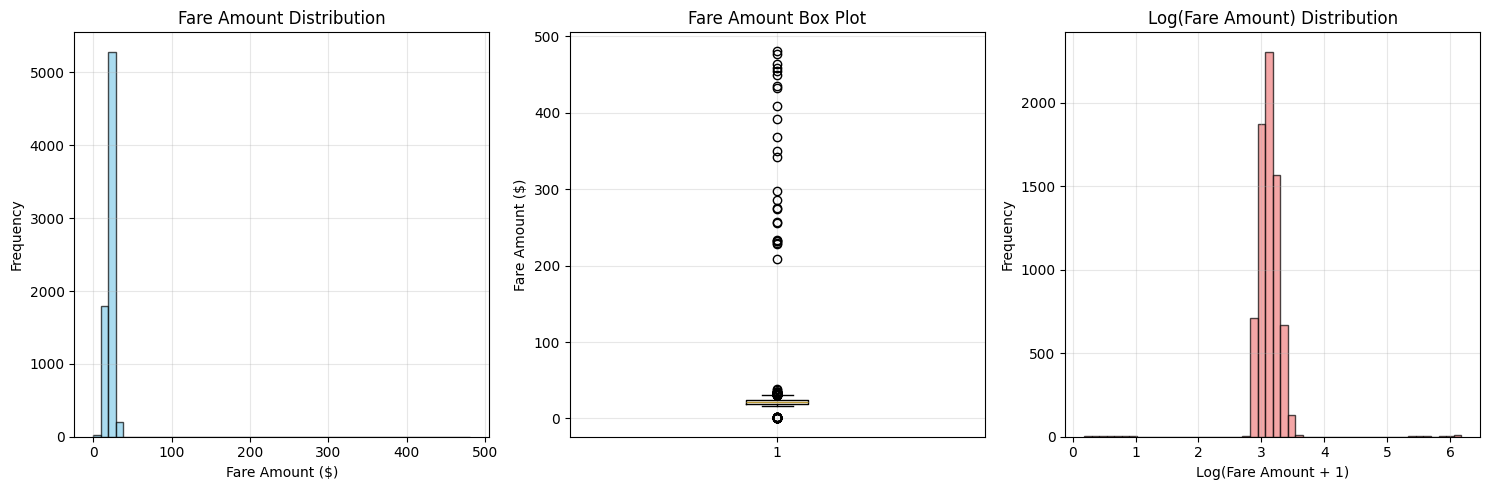

Fare statistics:
Mean: $22.93
Median: $21.60
Standard deviation: $19.69
95th percentile: $27.90
99th percentile: $31.30


In [7]:
# Visualize fare distribution to identify outliers
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(df['fare_amount'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title("Fare Amount Distribution")
plt.xlabel("Fare Amount ($)")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.boxplot(df['fare_amount'])
plt.title("Fare Amount Box Plot")
plt.ylabel("Fare Amount ($)")
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
# Log scale to see distribution better
plt.hist(np.log1p(df['fare_amount']), bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
plt.title("Log(Fare Amount) Distribution")
plt.xlabel("Log(Fare Amount + 1)")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Show some statistics
print(f"Fare statistics:")
print(f"Mean: ${df['fare_amount'].mean():.2f}")
print(f"Median: ${df['fare_amount'].median():.2f}")
print(f"Standard deviation: ${df['fare_amount'].std():.2f}")
print(f"95th percentile: ${df['fare_amount'].quantile(0.95):.2f}")
print(f"99th percentile: ${df['fare_amount'].quantile(0.99):.2f}")

In [8]:
# Define outlier thresholds based on business logic
min_fare = 2.50  # NYC taxi minimum fare
max_fare = 200.0  # Reasonable maximum for city rides

# Identify outliers
outliers = df[(df['fare_amount'] < min_fare) | (df['fare_amount'] > max_fare)]
print(f"Found {len(outliers)} fare outliers ({len(outliers)/len(df)*100:.1f}% of data)")

if len(outliers) > 0:
    print("\nOutlier examples:")
    print("Low fare outliers:")
    print(outliers[outliers['fare_amount'] < min_fare]['fare_amount'].head())
    print("\nHigh fare outliers:")
    print(outliers[outliers['fare_amount'] > max_fare]['fare_amount'].head())

# Handle outliers - remove extreme cases
df_clean = df[(df['fare_amount'] >= min_fare) & (df['fare_amount'] <= max_fare)].copy()
print(f"\nDataset size after fare outlier removal: {len(df_clean):,} rows")
print(f"Removed {len(df) - len(df_clean):,} outlier records")

Found 50 fare outliers (0.7% of data)

Outlier examples:
Low fare outliers:
97      0.8
342     1.5
618     0.4
1089    1.4
1137    0.7
Name: fare_amount, dtype: float64

High fare outliers:
178     391.1
248     448.7
1180    255.6
1538    285.6
1764    476.1
Name: fare_amount, dtype: float64

Dataset size after fare outlier removal: 7,283 rows
Removed 50 outlier records


In [9]:
# Check coordinate outliers (NYC boundaries approximately)
# Manhattan/NYC area: roughly -74.3 to -73.7 longitude, 40.4 to 40.9 latitude
lat_bounds = (40.4, 40.9)
lon_bounds = (-74.3, -73.7)

print(f"Checking coordinates within NYC bounds:")
print(f"Latitude bounds: {lat_bounds}")
print(f"Longitude bounds: {lon_bounds}")

coord_outliers = df_clean[
    (df_clean['pickup_latitude'] < lat_bounds[0]) | 
    (df_clean['pickup_latitude'] > lat_bounds[1]) |
    (df_clean['pickup_longitude'] < lon_bounds[0]) | 
    (df_clean['pickup_longitude'] > lon_bounds[1]) |
    (df_clean['dropoff_latitude'] < lat_bounds[0]) | 
    (df_clean['dropoff_latitude'] > lat_bounds[1]) |
    (df_clean['dropoff_longitude'] < lon_bounds[0]) | 
    (df_clean['dropoff_longitude'] > lon_bounds[1])
]

print(f"\nFound {len(coord_outliers)} rides with coordinates outside NYC area")

# Remove coordinate outliers
df_clean = df_clean[
    (df_clean['pickup_latitude'].between(lat_bounds[0], lat_bounds[1])) &
    (df_clean['pickup_longitude'].between(lon_bounds[0], lon_bounds[1])) &
    (df_clean['dropoff_latitude'].between(lat_bounds[0], lat_bounds[1])) &
    (df_clean['dropoff_longitude'].between(lon_bounds[0], lon_bounds[1]))
].copy()

print(f"Final dataset size after all cleaning: {len(df_clean):,} rows")
print(f"Total records removed: {len(df) - len(df_clean):,} ({(len(df) - len(df_clean))/len(df)*100:.1f}%)")

Checking coordinates within NYC bounds:
Latitude bounds: (40.4, 40.9)
Longitude bounds: (-74.3, -73.7)

Found 0 rides with coordinates outside NYC area
Final dataset size after all cleaning: 7,283 rows
Total records removed: 50 (0.7%)


**Code Explanation**: We examine missing values and basic data ranges to identify potential issues. We convert timestamps to proper datetime format and apply business logic to define reasonable fare ranges and geographical boundaries. NYC taxis have a minimum fare, and rides over $200 within the city are extremely rare and likely data errors.

## Step 3: Engineer Features (Time-of-Day, Trip Distance)

Feature engineering is crucial for creating a successful prediction model. We'll create both temporal and spatial features.

In [10]:
# Extract time-based features
print("Creating temporal features...")

df_clean['pickup_hour'] = df_clean['pickup_timestamp'].dt.hour
df_clean['pickup_day_of_week'] = df_clean['pickup_timestamp'].dt.dayofweek
df_clean['pickup_month'] = df_clean['pickup_timestamp'].dt.month
df_clean['pickup_year'] = df_clean['pickup_timestamp'].dt.year

# Create additional time categories
df_clean['is_weekend'] = df_clean['pickup_day_of_week'].isin([5, 6])  # Saturday=5, Sunday=6

# Define rush hour periods
def get_time_period(hour):
    if 6 <= hour <= 9:
        return 'morning_rush'
    elif 17 <= hour <= 19:
        return 'evening_rush'
    elif 22 <= hour or hour <= 5:
        return 'late_night'
    else:
        return 'regular'

df_clean['time_period'] = df_clean['pickup_hour'].apply(get_time_period)

print("Temporal features created:")
print("- pickup_hour: Hour of day (0-23)")
print("- pickup_day_of_week: Day of week (0=Monday, 6=Sunday)")
print("- pickup_month: Month (1-12)")
print("- pickup_year: Year")
print("- is_weekend: Boolean indicating weekend")
print("- time_period: Categorical time period")

# Show distribution of time periods
print("\nTime period distribution:")
print(df_clean['time_period'].value_counts())

Creating temporal features...
Temporal features created:
- pickup_hour: Hour of day (0-23)
- pickup_day_of_week: Day of week (0=Monday, 6=Sunday)
- pickup_month: Month (1-12)
- pickup_year: Year
- is_weekend: Boolean indicating weekend
- time_period: Categorical time period

Time period distribution:
time_period
regular         2772
late_night      2350
morning_rush    1251
evening_rush     910
Name: count, dtype: int64


In [11]:
# Calculate trip distance using Haversine formula
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate the great circle distance between two points 
    on the earth (specified in decimal degrees)
    """
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    # Radius of earth in kilometers
    r = 6371
    return c * r

print("Creating spatial features...")

# Calculate trip distance
df_clean['trip_distance_km'] = haversine_distance(
    df_clean['pickup_latitude'], df_clean['pickup_longitude'],
    df_clean['dropoff_latitude'], df_clean['dropoff_longitude']
)

# Calculate distance from Manhattan center (Times Square: 40.7580, -73.9855)
manhattan_center = (40.7580, -73.9855)

df_clean['pickup_distance_from_center'] = haversine_distance(
    df_clean['pickup_latitude'], df_clean['pickup_longitude'],
    manhattan_center[0], manhattan_center[1]
)

df_clean['dropoff_distance_from_center'] = haversine_distance(
    df_clean['dropoff_latitude'], df_clean['dropoff_longitude'],
    manhattan_center[0], manhattan_center[1]
)

print("Spatial features created:")
print("- trip_distance_km: Distance between pickup and dropoff")
print("- pickup_distance_from_center: Distance from Manhattan center")
print("- dropoff_distance_from_center: Distance to Manhattan center")

print(f"\nTrip distance statistics:")
print(f"Min: {df_clean['trip_distance_km'].min():.3f} km")
print(f"Max: {df_clean['trip_distance_km'].max():.3f} km")
print(f"Mean: {df_clean['trip_distance_km'].mean():.3f} km")
print(f"Median: {df_clean['trip_distance_km'].median():.3f} km")

Creating spatial features...
Spatial features created:
- trip_distance_km: Distance between pickup and dropoff
- pickup_distance_from_center: Distance from Manhattan center
- dropoff_distance_from_center: Distance to Manhattan center

Trip distance statistics:
Min: 0.011 km
Max: 4.966 km
Mean: 1.236 km
Median: 1.157 km


In [12]:
# Validate engineered features
print("Validating engineered features...")

# Check for any impossible values (e.g., zero distance)
zero_distance = (df_clean['trip_distance_km'] < 0.1).sum()
print(f"Trips with distance < 0.1 km: {zero_distance}")

# Remove zero-distance trips (likely data errors)
if zero_distance > 0:
    df_clean = df_clean[df_clean['trip_distance_km'] >= 0.1].copy()
    print(f"Removed {zero_distance} zero-distance trips")

# Check for extremely long trips (possible errors)
long_trips = (df_clean['trip_distance_km'] > 100).sum()
print(f"Trips longer than 100 km: {long_trips}")

if long_trips > 0:
    print("Long trip examples:")
    long_trip_examples = df_clean[df_clean['trip_distance_km'] > 100][['trip_distance_km', 'fare_amount']].head()
    print(long_trip_examples)

print(f"\nFinal dataset size: {len(df_clean):,} rows")

Validating engineered features...
Trips with distance < 0.1 km: 40
Removed 40 zero-distance trips
Trips longer than 100 km: 0

Final dataset size: 7,243 rows


In [13]:
# Save the prepared dataset
df_clean.to_csv('taxi_prepared.csv', index=False)
print(f"Prepared dataset saved as 'taxi_prepared.csv'")
print(f"Dataset contains {len(df_clean):,} rows and {df_clean.shape[1]} columns")
print("\nDataset is now ready for machine learning model training!")

# Show a sample of the final dataset
print("\nSample of prepared dataset:")
df_clean.head()

Prepared dataset saved as 'taxi_prepared.csv'
Dataset contains 7,243 rows and 15 columns

Dataset is now ready for machine learning model training!

Sample of prepared dataset:


,fare_amount,pickup_timestamp,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,pickup_hour,pickup_day_of_week,pickup_month,pickup_year,is_weekend,time_period,trip_distance_km,pickup_distance_from_center,dropoff_distance_from_center
0,26.0,2013-05-10 14:42:07+00:00,-73.981828,40.750499,-73.961214,40.748411,14,4,5,2013,False,regular,1.751936,0.889575,2.306888
1,21.5,2013-11-10 06:57:18+00:00,-73.960184,40.776519,-73.957553,40.765177,6,6,11,2013,True,morning_rush,1.280486,2.964086,2.485381
2,24.3,2011-11-27 10:23:52+00:00,-73.988015,40.798280,-73.974500,40.787364,10,6,11,2011,True,regular,1.663659,4.483935,3.393977
3,23.6,2013-05-21 23:02:21+00:00,-73.994930,40.699435,-73.994619,40.683525,23,1,5,2013,False,late_night,1.769306,6.560431,8.316824
4,21.0,2013-02-08 23:43:29+00:00,-74.025075,40.740455,-74.017560,40.748130,23,4,2,2013,False,late_night,1.062610,3.862622,2.915019


## Key Takeaways

1. **Data Quality is Critical**: Real-world data often contains errors, outliers, and missing values that must be addressed before modeling.

2. **Feature Engineering Drives Performance**: Creating meaningful features from raw data (like extracting time periods from timestamps) often has more impact than choosing different algorithms.

3. **Domain Knowledge Matters**: Understanding taxi operations (rush hours, minimum fares, NYC geography) helps in both cleaning data and creating relevant features.

4. **Validation is Essential**: Always visualize and validate your engineered features to ensure they make business sense.

5. **Documentation Helps**: Keep track of what each feature represents and how it was created for future reference.

## Next Steps

With your prepared dataset, you're now ready to:
- Split the data into training and testing sets
- Try different machine learning algorithms (linear regression, random forest, etc.)
- Evaluate model performance using appropriate metrics
- Fine-tune hyperparameters for better predictions

The quality of your data preparation will significantly impact your model's performance, so the work done in this lab forms the foundation for successful fare prediction!